# Multi-device JAX: direct N-body forces with `all_gather`

This focused tutorial distributes particles evenly over the devices of one host. Each device owns a subset of the **target** particles, gathers every device's source particles with `jax.lax.all_gather`, and then computes the accelerations of its local targets. The example is deliberately small: its purpose is to make the communication pattern visible, not to present a scalable astrophysics code.

After completing the notebook, you should be able to:

- describe the local and global particle-array shapes seen by each device;
- use `Mesh`, `PartitionSpec`, and `shard_map` to express particle ownership;
- explain why `all_gather(..., tiled=True)` gives every device the complete source array;
- validate a distributed force calculation against a single-device reference; and
- identify the communication and computational scaling limits of this decomposition.

**Prerequisites:** basic JAX array programming, Newtonian gravity, and time integration. The single-device `n_body.ipynb` provides the physical and numerical background. Allow about 30–45 minutes.

**Execution:** use a host with at least two visible GPUs, or start Jupyter with `JAX_MULTI_DEVICE_CPU_EMULATION=1 jupyter lab` to create four virtual CPU devices. CPU emulation checks the program logic only; it says nothing about multi-GPU performance. Compact outputs are intentionally retained for static viewing.

## 1. The decomposition

Let $N$ be the number of bodies, $P$ the number of devices, and $d$ the number of spatial dimensions. We require $N$ to be divisible by $P$. Before communication, device $p$ owns arrays with shapes

- local positions: $(N/P, d)$;
- local velocities: $(N/P, d)$;
- local masses: $(N/P,)$.

A direct gravitational force is long-ranged: every target body needs the position and mass of every source body. An all-gather concatenates the $P$ local source blocks, so each device temporarily has positions with shape $(N,d)$ and masses with shape $(N,)$. It still returns accelerations only for that device's $N/P$ targets.

```text
device 0: sources 0..1  --\
device 1: sources 2..3  ---- all_gather --> every device: sources 0..7
device 2: sources 4..5  ----/                 |
device 3: sources 6..7  --/                   +--> local target accelerations
```

## 2. Configure JAX before querying devices

JAX device configuration must happen before the first device query. We use 64-bit arithmetic so that strict reference comparisons and conservation checks are meaningful. On many consumer GPUs, 64-bit arithmetic is much slower than 32-bit arithmetic; set `JAX_ENABLE_X64=0` when throughput matters more than these tight tolerances.

In [1]:
import os
from functools import partial

import jax

if os.environ.get("JAX_MULTI_DEVICE_CPU_EMULATION", "0") == "1":
    jax.config.update("jax_platform_name", "cpu")
    jax.config.update("jax_num_cpu_devices", 4)

USE_X64 = os.environ.get("JAX_ENABLE_X64", "1") != "0"
jax.config.update("jax_enable_x64", USE_X64)

import matplotlib.pyplot as plt
import numpy as np
import jax.numpy as jnp
from jax import lax
from jax.sharding import Mesh, NamedSharding, PartitionSpec as P

devices = jax.devices()
if len(devices) < 2:
    raise RuntimeError(
        "This notebook needs at least two devices. On a CPU-only machine, "
        "restart Jupyter with JAX_MULTI_DEVICE_CPU_EMULATION=1."
    )

AXIS_NAME = "devices"
mesh = Mesh(np.asarray(devices), (AXIS_NAME,))
particle_sharding = NamedSharding(mesh, P(AXIS_NAME, None))
mass_sharding = NamedSharding(mesh, P(AXIS_NAME))

print(f"JAX {jax.__version__}")
print(f"Backend: {jax.default_backend()}")
print(f"Devices ({len(devices)}): {devices}")
print(f"64-bit enabled: {jax.config.x64_enabled}")

JAX 0.10.2
Backend: cpu
Devices (4): [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3)]
64-bit enabled: True


## 3. Construct and shard a small system

The system contains one central body and seven light satellites. Their tangential velocities approximate circular orbits around the central mass. The satellites also interact with one another, so these are not exact circular solutions. We shift positions and velocities into the centre-of-mass frame.

The normalized gravitational constant is $G=1$. The particle count is fixed at eight so the example divides evenly over two, four, or eight devices.

In [2]:
N_BODIES = 8
N_DIMENSIONS = 2
GRAVITATIONAL_CONSTANT = 1.0
SOFTENING_LENGTH = 0.02

if N_BODIES % len(devices) != 0:
    raise ValueError(
        f"N_BODIES={N_BODIES} must be divisible by {len(devices)} devices."
    )

satellite_radii = jnp.linspace(0.7, 1.9, N_BODIES - 1)
satellite_angles = 2.0 * jnp.pi * jnp.arange(N_BODIES - 1) / (N_BODIES - 1)
radial_directions = jnp.stack(
    (jnp.cos(satellite_angles), jnp.sin(satellite_angles)), axis=1
)
tangential_directions = jnp.stack(
    (-jnp.sin(satellite_angles), jnp.cos(satellite_angles)), axis=1
)
satellite_positions = satellite_radii[:, None] * radial_directions
satellite_speeds = jnp.sqrt(GRAVITATIONAL_CONSTANT / satellite_radii)
satellite_velocities = satellite_speeds[:, None] * tangential_directions

reference_masses = jnp.concatenate(
    (jnp.array([1.0]), jnp.full((N_BODIES - 1,), 1.0e-3))
)
reference_positions_0 = jnp.concatenate(
    (jnp.zeros((1, N_DIMENSIONS)), satellite_positions), axis=0
)
reference_velocities_0 = jnp.concatenate(
    (jnp.zeros((1, N_DIMENSIONS)), satellite_velocities), axis=0
)
total_mass = jnp.sum(reference_masses)
reference_positions_0 -= jnp.sum(
    reference_masses[:, None] * reference_positions_0, axis=0
) / total_mass
reference_velocities_0 -= jnp.sum(
    reference_masses[:, None] * reference_velocities_0, axis=0
) / total_mass

positions_0 = jax.device_put(reference_positions_0, particle_sharding)
velocities_0 = jax.device_put(reference_velocities_0, particle_sharding)
masses = jax.device_put(reference_masses, mass_sharding)

print(f"Global positions: {positions_0.shape}, sharding: {positions_0.sharding.spec}")
for shard in positions_0.addressable_shards:
    print(f"{shard.device}: global rows {shard.index[0]}, local shape {shard.data.shape}")

Global positions: (8, 2), sharding: P('devices', None)
cpu:0: global rows slice(0, 2, None), local shape (2, 2)
cpu:1: global rows slice(2, 4, None), local shape (2, 2)
cpu:2: global rows slice(4, 6, None), local shape (2, 2)
cpu:3: global rows slice(6, 8, None), local shape (2, 2)


## 4. Direct gravitational acceleration

For target body $i$, the softened gravitational acceleration is

$$
\mathbf{a}_i = G \sum_{j=1}^{N} m_j
\frac{\mathbf{r}_j-\mathbf{r}_i}
{\left(\lVert\mathbf{r}_j-\mathbf{r}_i\rVert^2+\varepsilon^2\right)^{3/2}}.
$$

Here $\mathbf{a}_i$ is the acceleration of target $i$, $G$ is the gravitational constant, $m_j$ and $\mathbf{r}_j$ are the mass and position of source $j$, $\mathbf{r}_i$ is the target position, $N$ is the number of bodies, and $\varepsilon>0$ is a softening length. Softening avoids a singularity during close encounters. The self term $j=i$ is exactly zero because its displacement vector is zero.

Inside `shard_map`, `local_positions` and `local_masses` contain only $N/P$ bodies. `all_gather` concatenates the blocks along their existing particle axis because `tiled=True`. Every device then sees all $N$ sources but computes only its local targets.

In [3]:
@partial(
    jax.shard_map,
    mesh=mesh,
    in_specs=(P(AXIS_NAME, None), P(AXIS_NAME)),
    out_specs=P(AXIS_NAME, None),
    axis_names={AXIS_NAME},
)
def distributed_accelerations(local_positions, local_masses):
    all_positions = lax.all_gather(
        local_positions, AXIS_NAME, axis=0, tiled=True
    )
    all_masses = lax.all_gather(
        local_masses, AXIS_NAME, axis=0, tiled=True
    )

    displacements = all_positions[None, :, :] - local_positions[:, None, :]
    squared_distances = jnp.sum(displacements**2, axis=-1)
    inverse_distance_cubed = (
        squared_distances + SOFTENING_LENGTH**2
    ) ** (-1.5)
    weighted_displacements = (
        all_masses[None, :, None]
        * inverse_distance_cubed[:, :, None]
        * displacements
    )
    return GRAVITATIONAL_CONSTANT * jnp.sum(weighted_displacements, axis=1)

The two collectives are kept separate to make the position and mass shapes explicit. A tuned implementation might pack source fields into one buffer or replicate immutable masses once, but that optimization would distract from the communication pattern here.

The essential shape change on every device is:

| value | before `all_gather` | after `all_gather(..., tiled=True)` |
|---|---:|---:|
| positions | $(N/P,d)$ | $(N,d)$ |
| masses | $(N/P,)$ | $(N,)$ |
| returned accelerations | $(N/P,d)$ | not gathered |

## 5. Validate the collective against a reference

A multi-device result is not trustworthy merely because it runs. The reference below evaluates the same formula from global arrays on one device. Matching one acceleration evaluation isolates the decomposition and collective from the time integrator.

In [4]:
@jax.jit
def reference_accelerations(positions, particle_masses):
    displacements = positions[None, :, :] - positions[:, None, :]
    squared_distances = jnp.sum(displacements**2, axis=-1)
    inverse_distance_cubed = (
        squared_distances + SOFTENING_LENGTH**2
    ) ** (-1.5)
    return GRAVITATIONAL_CONSTANT * jnp.sum(
        particle_masses[None, :, None]
        * inverse_distance_cubed[:, :, None]
        * displacements,
        axis=1,
    )

distributed_a0 = distributed_accelerations(positions_0, masses)
reference_a0 = reference_accelerations(
    reference_positions_0, reference_masses
)
distributed_a0.block_until_ready()
acceleration_error = float(
    jnp.max(jnp.abs(distributed_a0 - reference_a0))
)
print(f"Maximum acceleration difference: {acceleration_error:.3e}")

Maximum acceleration difference: 0.000e+00


## 6. Integrate while keeping particles sharded

Velocity Verlet advances positions $\mathbf{r}$ and velocities $\mathbf{v}$ through one time step $\Delta t$:

$$
\begin{aligned}
\mathbf{v}_{n+1/2} &= \mathbf{v}_n + \tfrac{1}{2}\Delta t\,\mathbf{a}_n,\\
\mathbf{r}_{n+1} &= \mathbf{r}_n + \Delta t\,\mathbf{v}_{n+1/2},\\
\mathbf{v}_{n+1} &= \mathbf{v}_{n+1/2} + \tfrac{1}{2}\Delta t\,\mathbf{a}_{n+1}.
\end{aligned}
$$

The subscript $n$ denotes the time-step index, and $\mathbf{a}_n$ is the acceleration at $\mathbf{r}_n$. After the initial acceleration, each step requires one new force evaluation and therefore two all-gathers in this teaching implementation. `lax.scan` keeps the loop compiled; the trajectory history is retained only because we want to plot and validate it.

In [5]:
def build_simulator(acceleration_function):
    @partial(jax.jit, static_argnames=("n_steps",))
    def simulate_history(positions, velocities, particle_masses, dt, n_steps):
        accelerations = acceleration_function(positions, particle_masses)

        def step(state, _):
            current_positions, current_velocities, current_accelerations = state
            half_step_velocities = (
                current_velocities + 0.5 * dt * current_accelerations
            )
            next_positions = current_positions + dt * half_step_velocities
            next_accelerations = acceleration_function(
                next_positions, particle_masses
            )
            next_velocities = (
                half_step_velocities + 0.5 * dt * next_accelerations
            )
            next_state = (
                next_positions, next_velocities, next_accelerations
            )
            return next_state, (next_positions, next_velocities)

        initial_state = (positions, velocities, accelerations)
        _, (later_positions, later_velocities) = lax.scan(
            step, initial_state, xs=None, length=n_steps
        )
        position_history = jnp.concatenate(
            (positions[None, ...], later_positions), axis=0
        )
        velocity_history = jnp.concatenate(
            (velocities[None, ...], later_velocities), axis=0
        )
        return position_history, velocity_history

    return simulate_history


distributed_simulate_history = build_simulator(distributed_accelerations)
reference_simulate_history = build_simulator(reference_accelerations)

In [6]:
DT = 0.005
N_STEPS = 1200

position_history, velocity_history = distributed_simulate_history(
    positions_0, velocities_0, masses, DT, N_STEPS
)
reference_position_history, reference_velocity_history = (
    reference_simulate_history(
        reference_positions_0,
        reference_velocities_0,
        reference_masses,
        DT,
        N_STEPS,
    )
)
position_history.block_until_ready()
reference_position_history.block_until_ready()

trajectory_error = float(
    jnp.max(jnp.abs(position_history - reference_position_history))
)
print(f"History shape: {position_history.shape}")
print(f"History sharding: {position_history.sharding.spec}")
print(f"Maximum trajectory difference: {trajectory_error:.3e}")

History shape: (1201, 8, 2)
History sharding: P(None, 'devices')
Maximum trajectory difference: 0.000e+00


The history is sharded along the particle dimension, not the time dimension. On the host, converting it with `np.asarray` gathers the full history. That is acceptable for this tiny plot, but a production run should avoid routinely materializing a large global trajectory on the host.

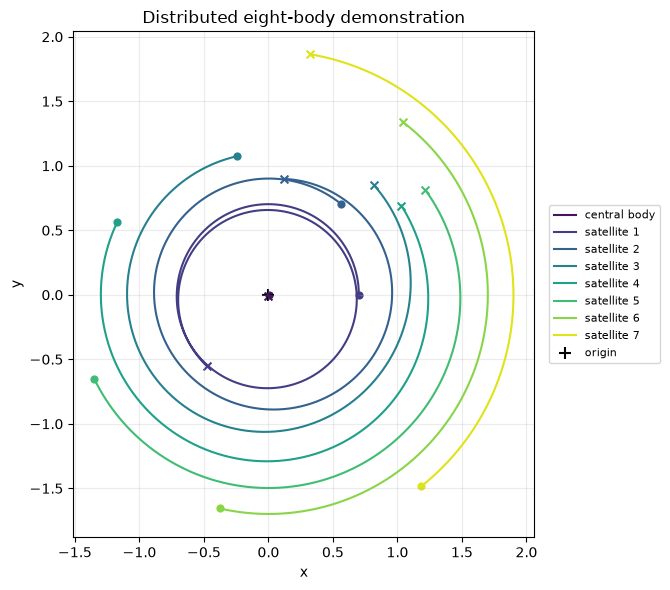

In [7]:
position_history_host = np.asarray(position_history)
initial_positions_host = position_history_host[0]
final_positions_host = position_history_host[-1]

fig, ax = plt.subplots(figsize=(8, 6))
colors = plt.cm.viridis(np.linspace(0.05, 0.95, N_BODIES))
for body_index, color in enumerate(colors):
    label = "central body" if body_index == 0 else f"satellite {body_index}"
    ax.plot(
        position_history_host[:, body_index, 0],
        position_history_host[:, body_index, 1],
        color=color,
        linewidth=1.5,
        label=label,
    )
    ax.scatter(
        *initial_positions_host[body_index],
        color=color,
        marker="o",
        s=24,
    )
    ax.scatter(
        *final_positions_host[body_index],
        color=color,
        marker="x",
        s=32,
    )

ax.scatter(0.0, 0.0, color="black", marker="+", s=80, label="origin")
ax.set(
    xlabel="x",
    ylabel="y",
    title="Distributed eight-body demonstration",
)
ax.set_aspect("equal", adjustable="box")
ax.grid(alpha=0.25)
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8)
fig.tight_layout()
plt.show()

## 7. Scientific diagnostics

The distributed/reference comparison tests the implementation. Conservation diagnostics test whether the simulated system behaves consistently with an isolated system. Total linear momentum and the centre of mass should remain constant up to floating-point error; total softened energy should have a small bounded integration error. These checks do not prove that the softened physical model is appropriate for a particular scientific application.

In [8]:
def diagnostics(positions, velocities, particle_masses):
    momenta = jnp.sum(
        particle_masses[None, :, None] * velocities, axis=1
    )
    centres_of_mass = jnp.sum(
        particle_masses[None, :, None] * positions, axis=1
    ) / jnp.sum(particle_masses)

    kinetic_energy = 0.5 * jnp.sum(
        particle_masses[None, :, None] * velocities**2, axis=(1, 2)
    )
    pair_displacements = positions[:, :, None, :] - positions[:, None, :, :]
    pair_distances = jnp.sqrt(
        jnp.sum(pair_displacements**2, axis=-1) + SOFTENING_LENGTH**2
    )
    pair_masses = particle_masses[:, None] * particle_masses[None, :]
    upper_triangle = jnp.triu(
        jnp.ones((N_BODIES, N_BODIES), dtype=bool), k=1
    )
    potential_energy = -GRAVITATIONAL_CONSTANT * jnp.sum(
        jnp.where(
            upper_triangle[None, :, :],
            pair_masses[None, :, :] / pair_distances,
            0.0,
        ),
        axis=(1, 2),
    )
    return momenta, centres_of_mass, kinetic_energy + potential_energy


momenta, centres_of_mass, total_energies = diagnostics(
    position_history, velocity_history, masses
)
momentum_drift = float(jnp.max(jnp.linalg.norm(momenta - momenta[0], axis=1)))
centre_of_mass_drift = float(
    jnp.max(jnp.linalg.norm(centres_of_mass - centres_of_mass[0], axis=1))
)
relative_energy_error = float(
    jnp.max(jnp.abs((total_energies - total_energies[0]) / total_energies[0]))
)

print(f"Maximum momentum drift: {momentum_drift:.3e}")
print(f"Maximum centre-of-mass drift: {centre_of_mass_drift:.3e}")
print(f"Maximum relative energy error: {relative_energy_error:.3e}")

Maximum momentum drift: 1.424e-17
Maximum centre-of-mass drift: 2.196e-17
Maximum relative energy error: 4.625e-07


## 8. What this example teaches—and what it does not

### Advantages

- Particle ownership is simple and perfectly balanced when every body costs roughly the same amount of work.
- The force calculation is easy to compare with a single-device vectorized reference.
- `all_gather` is physically motivated: gravity is long-ranged, so every local target needs every source in a direct summation.

### Scaling limitations

- Direct summation costs $O(N^2/P)$ arithmetic per device.
- Every force evaluation communicates $O(Nd)$ position data and $O(N)$ mass data to every device, and temporarily replicates those global source arrays on every device.
- An all-gather is a collective synchronization point. More GPUs can make a small problem slower when communication dominates the local force calculation.
- Dividing particles by their array index ignores spatial locality. Dividing by space instead introduces particle migration, variable occupancy, load balancing, and still does not make a long-range $1/r^2$ interaction local.

Production N-body codes therefore use algorithms such as Barnes–Hut trees, the fast multipole method, particle–mesh methods, or hybrids. Those methods change both the numerical approximation and the communication pattern. This notebook intentionally does neither: it is an `all_gather` lesson, not a scalable gravity solver.

Here $O(\cdot)$ denotes asymptotic cost, $r$ is source–target distance, and $N$, $P$, and $d$ retain their definitions from Section 1.

## 9. Automated checks and takeaways

The final cell makes the notebook fail visibly if its main claims no longer hold. Tolerances are looser for 32-bit arithmetic.

In [9]:
comparison_tolerance = 1.0e-12 if USE_X64 else 2.0e-5
conservation_tolerance = 1.0e-10 if USE_X64 else 2.0e-5
energy_tolerance = 2.0e-4

assert acceleration_error < comparison_tolerance
assert trajectory_error < comparison_tolerance
assert momentum_drift < conservation_tolerance
assert centre_of_mass_drift < conservation_tolerance
assert relative_energy_error < energy_tolerance
print("All distributed, reference, and conservation checks passed.")

All distributed, reference, and conservation checks passed.


The durable ideas are:

- `PartitionSpec(AXIS_NAME, None)` gives each device a block of particle rows.
- `shard_map` exposes the per-device view, where explicit collectives are meaningful.
- `all_gather(..., axis=0, tiled=True)` concatenates the local particle blocks into the global source array on every device.
- The outputs remain partitioned because each device computes only its local targets.
- Correctness validation and scaling analysis are separate obligations. CPU emulation can establish the former, never the latter.

### Further reading

- JAX API: [`jax.lax.all_gather`](https://docs.jax.dev/en/latest/_autosummary/jax.lax.all_gather.html)
- JAX: [Manual parallelism with `shard_map`](https://docs.jax.dev/en/latest/201/shard-map.html)
- JAX: [Distributed arrays and automatic parallelization](https://docs.jax.dev/en/latest/201/sharding.html)